In [19]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import random_split, Subset
import numpy as np
import copy
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import ConfusionMatrixDisplay


# Getting the same results with train and train_manual_update
- Write torch.manual_seed(42) at the beginning of your notebook.
- Write torch.set_default_dtype(torch.double) at the beginning of your notebook to alleviate precision errors

In [20]:
torch.manual_seed(42)
torch.set_default_dtype(torch.double)

# Tasks
Load, analyse and preprocess the CIFAR-10 dataset. Split it into 3
datasets: training, validation and test. Take a subset of these datasets
by keeping only 2 labels: bird and plane

In [21]:
def load_cifar2(train_val_split=0.9, data_path="../data/"):
    # Get split indices (no normalization needed yet) 
    base = datasets.CIFAR10(data_path, train=True, download=True, transform=None)

    n_train = int(len(base) * train_val_split)
    n_val = len(base) - n_train

    # We only need indices, so we split a dummy dataset length-wise
    idx_train, idx_val = random_split(
        range(len(base)), [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    idx_train = list(idx_train)
    idx_val = list(idx_val)

    # Compute mean/std from TRAIN indices only
    imgs = base.data[idx_train] / 255.0   # (N,32,32,3), float in [0,1]
    mean = imgs.mean(axis=(0,1,2))
    std  = imgs.std(axis=(0,1,2))

    # Define preprocessing using train stats 
    preprocessor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean.tolist(), std.tolist())
    ])

    # Create normalized datasets 
    full_train = datasets.CIFAR10(data_path, train=True, download=False, transform=preprocessor)
    train_set = Subset(full_train, idx_train)
    val_set   = Subset(full_train, idx_val)

    test_set = datasets.CIFAR10(data_path, train=False, download=True, transform=preprocessor)

    print(f"Train size: {len(train_set)}")
    print(f"Validation size: {len(val_set)}")
    print(f"Test size: {len(test_set)}")

    # --- Step 5: filter airplane(0) and bird(2), remap labels to {0,1} ---
    label_map = {0: 0, 2: 1}

    cifar2_train = [(x, label_map[y]) for x, y in train_set if y in (0, 2)]
    cifar2_val   = [(x, label_map[y]) for x, y in val_set   if y in (0, 2)]
    cifar2_test  = [(x, label_map[y]) for x, y in test_set  if y in (0, 2)]

    print(f"Train size: {len(cifar2_train)}")
    print(f"Validation size: {len(cifar2_val)}")
    print(f"Test size: {len(cifar2_test)}")
    bird_plane_ratio_train = sum(1 for _, label in cifar2_train if label == 1) / len(cifar2_train)
    print(f"Ratio of birds in training set: {bird_plane_ratio_train:.3f}")

    return cifar2_train, cifar2_val, cifar2_test, mean, std

    

cifar2_train, cifar2_val, cifar2_test, mean, std = load_cifar2()


def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            logits = model(data)
            pred = logits.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    return correct / total

Files already downloaded and verified


/opt/miniconda3/envs/INF265/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Train size: 45000
Validation size: 5000
Test size: 10000
Train size: 8980
Validation size: 1020
Test size: 2000
Ratio of birds in training set: 0.498


Write a MyMLP class that implements a MLP in PyTorch (so only fully
connected layers) such that:
    
    - The input dimension is 768(= 16 ∗ 16 ∗ 3) and the output dimension is 2 (for the 2 classes).
    - The hidden layers have respectively 128 and 32 hidden units.
    - All activation functions are ReLU. The last layer has no activation function since the cross-entropy loss already includes a softmax activation
function.

In [22]:
class MyNet(nn.Module):
    def __init__(self, hidden_sizes=None, dropout_rate=0):
        super(MyNet, self).__init__()
        if hidden_sizes is None:
            hidden_sizes = [512, 128, 32]

        layers = []
        in_features = 3072

        for i in range(len(hidden_sizes)):
            h = hidden_sizes[i]
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate)) #
            in_features = h

        layers.append(nn.Linear(in_features, 2))  # output layer

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.flatten(x, 1)  # (B, 3, 32, 32) -> (B, 3072)
        return self.network(x)

Write a train(n_epochs, optimizer, model, loss_fn, train_loader) function that trains model for n_epochs epochs given an optimizer optimizer, a loss function loss_fn and a dataloader train_loader.

In [23]:


def train(n_epochs, optimizer, model, loss_fn, train_loader, val_loader=None):
    train_losses, val_losses, val_accs = [], [], []
    best_state = None
    best_acc = float("-inf")
    best_epoch = None

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for data, target in train_loader:
            out = model(data)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(out, target)
            loss.backward()
            optimizer.step()

            bs = data.size(0)
            running_loss += loss.item() * bs
            n_samples += bs

        train_losses.append(running_loss / n_samples)

        if val_loader is not None:
            model.eval()
            # val loss
            vloss = 0.0
            v_samples = 0
            with torch.no_grad():
                for data, target in val_loader:
                    out = model(data)
                    loss = loss_fn(out, target)
                    bs = data.size(0)
                    vloss += loss.item() * bs
                    v_samples += bs
            val_losses.append(vloss / v_samples)

            # val acc
            vacc = compute_accuracy(model, val_loader)
            val_accs.append(vacc)

            # save best epoch weights
            if vacc > best_acc:
                best_acc = vacc
                best_epoch = epoch + 1
                best_state = copy.deepcopy(model.state_dict())

    return model, train_losses, val_losses, val_accs, best_state, best_epoch, best_acc

Write a similar function train manual_update that has no optimizer parameter, but a learning rate lr parameter instead and that manually updates each trainable parameter of model using equation (2). Do not forget to zero out all gradients after each iteration. 

Train 2 instances of MyMLP, one using train and the other using train_manual_update (use the same parameter values for both models). Compare their respective training losses. To get exactly the same results with both functions, see section 3.3

In [24]:
def train_manual_update(n_epochs, model, loss_fn, train_loader,
                        lr=1e-2, momentum_coeff=0.0, weight_decay=0.0):
    model.train()
    velocity = {id(p): torch.zeros_like(p) for p in model.parameters() if p.requires_grad}
    epoch_losses = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0
        n_samples = 0

        for data, target in train_loader:
            model.zero_grad(set_to_none=True)
            
            output = model(data)
            loss = loss_fn(output, target)

            loss.backward()

            # manual SGD step (PER BATCH)
            with torch.no_grad():
                for p in model.parameters():
                    if not p.requires_grad or p.grad is None:
                        continue

                    grad = p.grad

                    # weight decay like PyTorch SGD: grad += wd * p
                    if weight_decay != 0.0:
                        grad = grad.add(p, alpha=weight_decay)

                    if momentum_coeff != 0.0:
                        v = velocity[id(p)]
                        v.mul_(momentum_coeff).add_(grad)
                        p.add_(v, alpha=-lr)
                    else:
                        p.add_(grad, alpha=-lr)

                    p.grad = None  # zero grad

            bs = data.size(0)
            running_loss += loss.item() * bs
            n_samples += bs

        epoch_losses.append(running_loss / n_samples)

    return model, epoch_losses


# Comparison of train vs train_manual_update and their respective losses

In [25]:
def comparison(weight_decay=0.0, momentum_coeff=0.0):
    model = MyNet()
    model2 = copy.deepcopy(model)

    optimizer = optim.SGD(model.parameters(), lr=1e-2, weight_decay=weight_decay, momentum=momentum_coeff)
    loss_fn = nn.CrossEntropyLoss()
    train_loader = torch.utils.data.DataLoader(cifar2_train, batch_size=64, shuffle=False)
    epochs = 5

    model, losses, _, _, _, _, _ = train(epochs, optimizer, model, loss_fn, train_loader)
    model2, losses2 = train_manual_update(epochs, model2, loss_fn, train_loader, weight_decay=weight_decay, momentum_coeff=momentum_coeff, lr=1e-2)

    comparison = allclose_list(losses, losses2)
    return comparison

def allclose_list(a, b, tol=1e-8):
    if len(a) != len(b): 
        return False
    return all(abs(x - y) < tol for x, y in zip(a, b))

In [26]:
comparison_no_weight_and_momentum = comparison()
comparison_weight = comparison(weight_decay=1e-4)
comparison_weight_and_momentum = comparison(weight_decay=1e-4, momentum_coeff=0.9)
print("Comparison without weight decay and momentum:", comparison_no_weight_and_momentum)
print("Comparison with weight decay:", comparison_weight)
print("Comparison with weight decay and momentum:", comparison_weight_and_momentum)

Comparison without weight decay and momentum: True
Comparison with weight decay: True
Comparison with weight decay and momentum: True


# Pipeline

## Visualizations

In [27]:
def unnormalize(img, mean, std):
    """
    img: torch.Tensor of shape (3, H, W), normalized
    returns: torch.Tensor in [0,1]
    """
    mean = torch.as_tensor(mean, device=img.device).view(3, 1, 1)
    std  = torch.as_tensor(std,  device=img.device).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1)

In [28]:
def display_images_norm_vs_unnorm(data_set,mean, std, save=False):
    fig, axes = plt.subplots(8, 4, constrained_layout=True, figsize=(8, 10))
    fig.suptitle("Normalized vs Unnormalized (Planes = 0, Birds = 1)")

    it = iter(data_set)

    col_titles = ["Norm Plane", "Unnorm Plane", "Norm Bird", "Unnorm Bird"]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title)

    for i in range(8):
        for cls in [0, 1]:
            while True:
                img, label = next(it)
                label = int(label.item()) if hasattr(label, "item") else int(label)
                if label == cls:
                    break

            # normalized image (for display we still need CHW -> HWC)
            img_norm = img.permute(1, 2, 0).cpu().numpy()

            # unnormalized image
            img_unnorm = unnormalize(img, mean, std)
            img_unnorm = img_unnorm.permute(1, 2, 0).cpu().numpy()

            col = 2 * cls
            axes[i, col].imshow(img_norm)
            axes[i, col + 1].imshow(img_unnorm)

            axes[i, col].axis("off")
            axes[i, col + 1].axis("off")

    if save:
        plt.savefig("imgs/norm_vs_unnorm.png", dpi=200)
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9104972341756414..2.040337849385262].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.87875407200179..1.5156243601561241].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4026066393940189..1.7405015698257549].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4026066393940189..1.0059026849049615].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5613224502632759..1.62886534820879].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4819645448286474..1.1258371967287646].
Clipping input data to the 

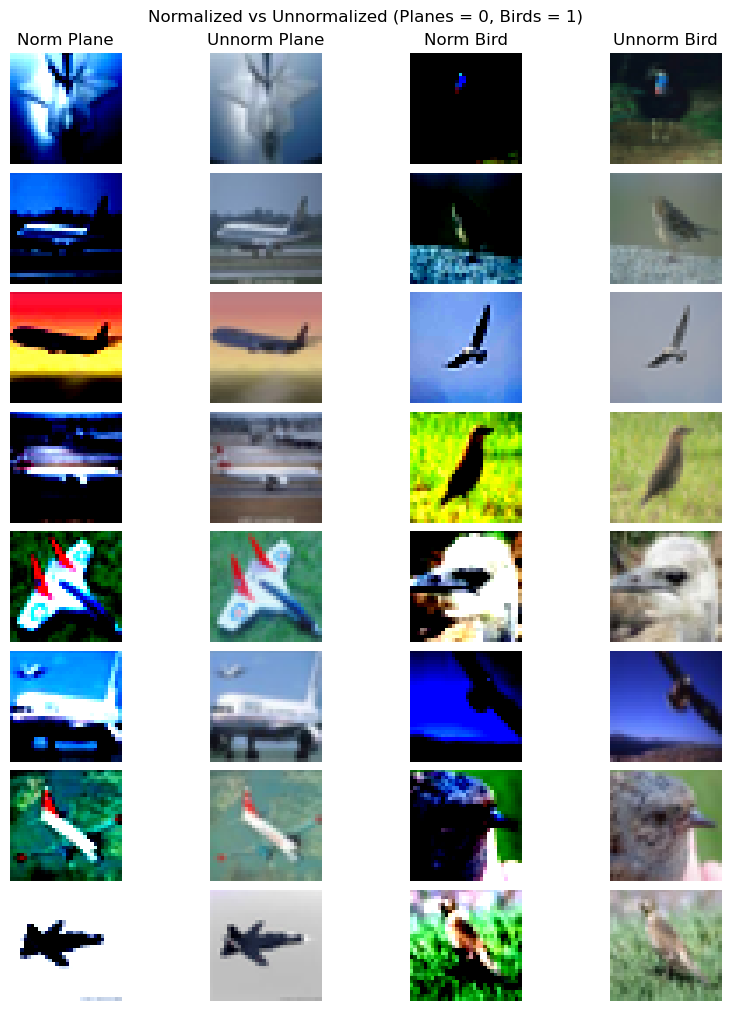

Class distribution: 
Label: 1 -> 4468 images
Label: 0 -> 4512 images


In [29]:
display_images_norm_vs_unnorm(cifar2_train,mean, std, save=True)

print("Class distribution: ")
counter = Counter([label for _, label in cifar2_train])
for label, count in counter.items():
    print(f"Label: {label} -> {count} images")

## Model architecture optimalization

In [30]:
def evaluate_model():
    results = {}
    best_key = None
    best_score = float("-inf")
    best_model = None
    best_state = None

    g = torch.Generator()
    g.manual_seed(0)
    
    torch.manual_seed(0)

    loss_fn = nn.CrossEntropyLoss()
    train_loader = torch.utils.data.DataLoader(cifar2_train, batch_size=64, shuffle=True, generator=g)
    val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False, generator=g)
    architecture = [
        {"name": "baseline", "hidden_sizes":[512, 128, 32]},
        {"name": "depth",    "hidden_sizes":[512, 256, 128, 64, 32]},
        {"name": "width",    "hidden_sizes":[1024, 128, 32]},
        {"name": "dropout",  "hidden_sizes":[512, 128, 32], "dropout_rate": 0.3}
    ]
    hyper_params = [
        {"lr": 0.01, "weight_decay": 0.0, "momentum": 0.0,},
        {"lr": 0.01, "weight_decay": 1e-4, "momentum": 0.9},
        {"lr": 0.01, "weight_decay": 0.0, "momentum": 0.9},
        {"lr": 0.01, "weight_decay": 0.01, "momentum": 0.9}
    ]
    epochs = 20
    

    for arch in architecture:
        for params in hyper_params:
            dropout = arch.get("dropout_rate", 0.0)

            model = MyNet(hidden_sizes=arch["hidden_sizes"], dropout_rate=dropout)

            optimizer = optim.SGD(model.parameters(), 
                                  lr=params["lr"], 
                                  weight_decay=params["weight_decay"], 
                                  momentum=params["momentum"])
            
            print(f"Training model with architecture: {arch}, hyperparameters: {params}, epochs: {epochs}, dropout_rate: {dropout}")
            model, train_losses, val_losses, val_accs, state, ep, acc = train(epochs, optimizer, model, loss_fn, train_loader, val_loader)

            key = (arch["name"], tuple(arch["hidden_sizes"]),
                   params["lr"], params["weight_decay"], params["momentum"],
                   epochs, dropout)
            

            results[key] = {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "val_accs": val_accs,
                "best_val_acc": acc,
                "best_epoch": ep,
                "final_val_acc": val_accs[-1],
                "final_val_loss": val_losses[-1],
            }

            if acc > best_score:
                best_score = acc
                best_key = key
                best_state = state

    best_arch_name, best_hidden, lr, wd, mom, epochs, best_dropout = best_key
    best_model = MyNet(hidden_sizes=list(best_hidden), dropout_rate=best_dropout)
    best_model.load_state_dict(best_state)

    return results, best_key, best_model


results, best_key, best_model = evaluate_model()


Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.0}, epochs: 20, dropout_rate: 0.0
Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.0001, 'momentum': 0.9}, epochs: 20, dropout_rate: 0.0
Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.9}, epochs: 20, dropout_rate: 0.0
Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.01, 'momentum': 0.9}, epochs: 20, dropout_rate: 0.0
Training model with architecture: {'name': 'depth', 'hidden_sizes': [512, 256, 128, 64, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.0}, epochs: 20, dropout_rate: 0.0
Training model with architecture: {'name': 'depth', 'hi

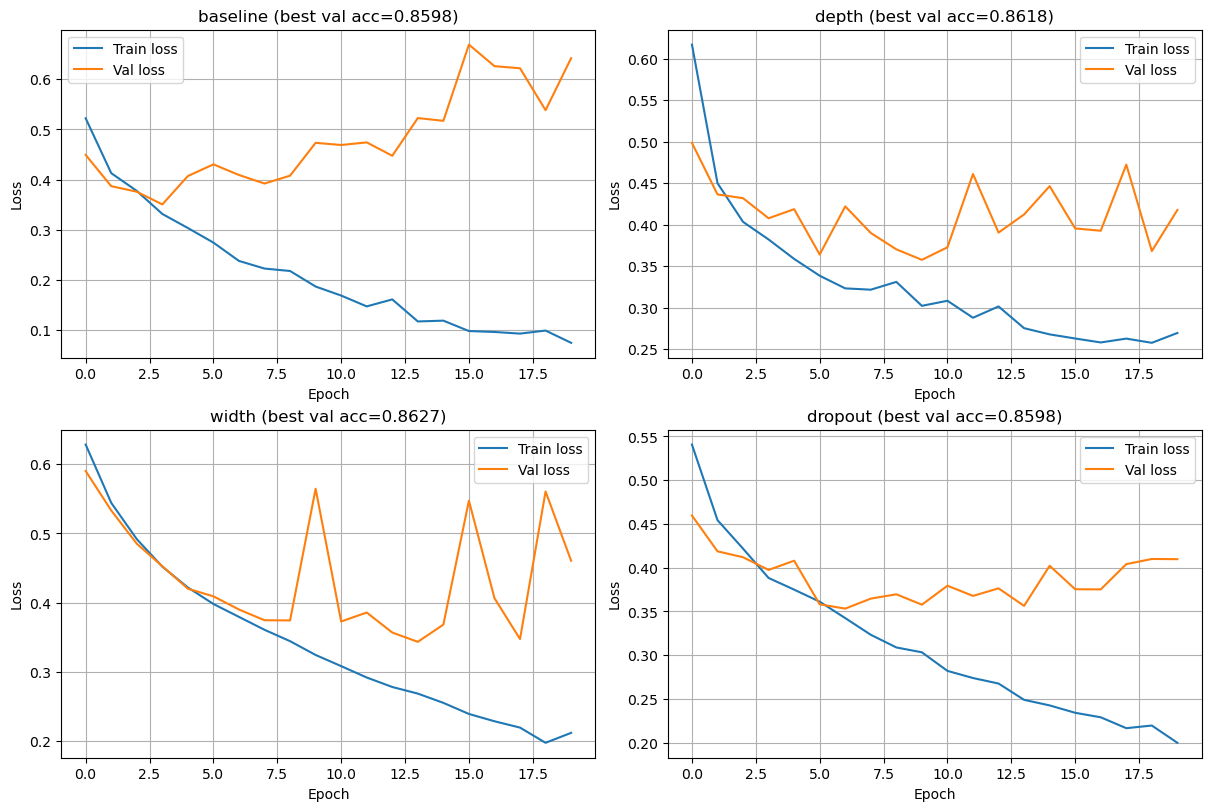

In [31]:
def plot_val_loss_best_by_acc(results, savepath="imgs/val_loss_best_by_acc.png"):
    # velg beste run per arkitektur basert på høyest validation accuracy
    best_by_arch = {}
    for key, info in results.items():
        arch_name = key[0]
        score = info["best_val_acc"]  # <-- ranger etter accuracy

        if arch_name not in best_by_arch or score > best_by_arch[arch_name][1]:
            best_by_arch[arch_name] = (key, score)

    order = ["baseline", "depth", "width", "dropout"]
    chosen = [(name, best_by_arch[name][0]) for name in order if name in best_by_arch]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    axes = axes.flatten()

    for ax, (arch_name, key) in zip(axes, chosen):
        tr_loss = results[key]["train_losses"]
        va_loss = results[key]["val_losses"]

        ax.plot(tr_loss, label="Train loss")
        ax.plot(va_loss, label="Val loss")

        ax.set_title(f"{arch_name} (best val acc={results[key]['best_val_acc']:.4f})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()

    for ax in axes[len(chosen):]:
        ax.axis("off")

    plt.savefig(savepath, dpi=200)
    plt.show()

plot_val_loss_best_by_acc(results)

In [32]:
best_epoch = 1 + results[best_key]["val_accs"].index(max(results[best_key]["val_accs"]))
best_val = max(results[best_key]["val_accs"])
print("Best model configuration:")
print("Architecture name:", best_key[0])
print("Hidden sizes:", best_key[1])
print("Learning rate:", best_key[2])
print("Weight decay:", best_key[3])
print("Momentum:", best_key[4])
print("Epochs:", best_key[5])
print("Dropout:", best_key[6])

best_epoch = 1 + results[best_key]["val_accs"].index(
    max(results[best_key]["val_accs"])
)
best_val_acc = max(results[best_key]["val_accs"])

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)


Best model configuration:
Architecture name: width
Hidden sizes: (1024, 128, 32)
Learning rate: 0.01
Weight decay: 0.0
Momentum: 0.0
Epochs: 20
Dropout: 0.0
Best epoch: 18
Best validation accuracy: 0.8627450980392157


In [33]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(cifar2_test, batch_size=64, shuffle=False)

val_accuracy = compute_accuracy(best_model, val_loader)
test_accuracy = compute_accuracy(best_model, test_loader)
print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")


Validation Accuracy: 0.863
Test Accuracy: 0.862


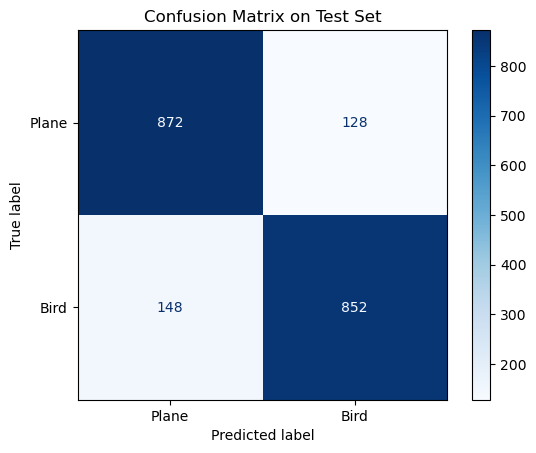

In [34]:
def confusion_matrix_binary(model, loader):
    model.eval()
    cm = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            pred = output.argmax(dim=1)
            for t, p in zip(target, pred):
                cm[int(t), int(p)] += 1

    return cm

cm = confusion_matrix_binary(best_model, test_loader)
cmplt = ConfusionMatrixDisplay(cm, display_labels=["Plane", "Bird"])
cmplt.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set")
plt.savefig("imgs/confusion_matrix.png", dpi=200)
plt.show()

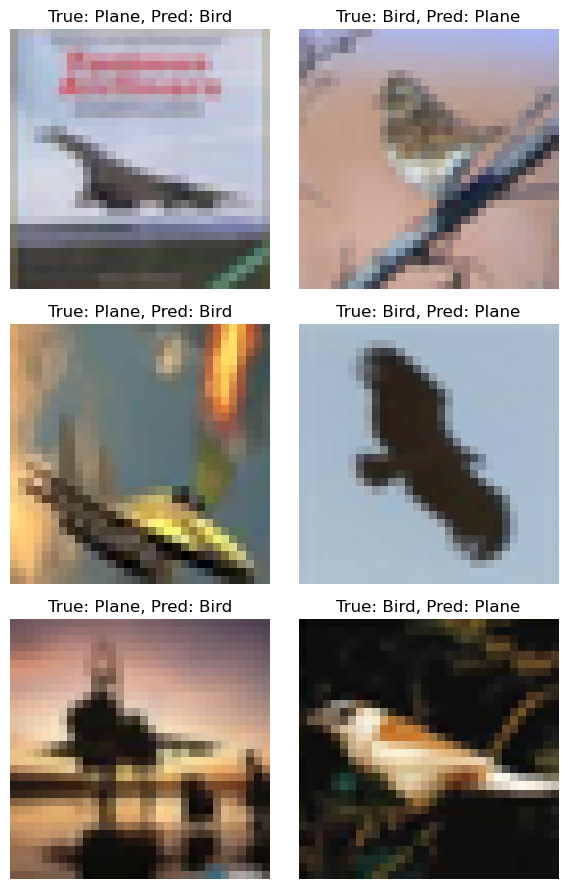

In [35]:
def show_misclassified_two_columns(model, dataset, n_per_col=3,
                                   class_names=("Plane", "Bird"),
                                   mean=mean,
                                   std=std):
    model.eval()

    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t  = torch.tensor(std).view(3, 1, 1)

    left_imgs = []   # (true=0, pred=1)
    right_imgs = []  # (true=1, pred=0)

    with torch.no_grad():
        for img, y_true in dataset:
            y_true = int(y_true)
            y_pred = int(model(img.unsqueeze(0)).argmax(1).item())

            if y_true == 0 and y_pred == 1 and len(left_imgs) < n_per_col:
                left_imgs.append(img)
            elif y_true == 1 and y_pred == 0 and len(right_imgs) < n_per_col:
                right_imgs.append(img)

            if len(left_imgs) >= n_per_col and len(right_imgs) >= n_per_col:
                break

    rows = n_per_col
    fig, axes = plt.subplots(rows, 2, figsize=(6, 3 * rows))

    for i in range(rows):
        # Left: True Plane, Pred Bird
        ax = axes[i, 0]
        if i < len(left_imgs):
            img = left_imgs[i]
            img_disp = (img.cpu() * std_t + mean_t).permute(1, 2, 0).numpy()
            img_disp = np.clip(img_disp, 0, 1)
            ax.imshow(img_disp)
        ax.set_title(f"True: {class_names[0]}, Pred: {class_names[1]}")
        ax.axis("off")

        # Right: True Bird, Pred Plane
        ax = axes[i, 1]
        if i < len(right_imgs):
            img = right_imgs[i]
            img_disp = (img.cpu() * std_t + mean_t).permute(1, 2, 0).numpy()
            img_disp = np.clip(img_disp, 0, 1)
            ax.imshow(img_disp)
        ax.set_title(f"True: {class_names[1]}, Pred: {class_names[0]}")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("imgs/misclassifications.png", dpi=200)
    plt.show()


show_misclassified_two_columns(best_model, cifar2_test, n_per_col=3)
